In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed.
# The notebook is written to run locally from the same folder as hypothyroid.csv,
# and also supports Kaggle-style input paths if needed.

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

try:
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
except Exception:
    device = "cpu"
    print("Using device:", device)


Using device: cpu


In [14]:
DATA_PATHS = [
    "/kaggle/input/datasets/yasserhessein/thyroid-disease-data-set/hypothyroid/hypothyroid.csv",
]

for path in DATA_PATHS:
    if os.path.exists(path):
        data_path = path
        break
else:
    raise FileNotFoundError("Could not find hypothyroid.csv. Place it beside this notebook or update DATA_PATHS.")

df = pd.read_csv(data_path)
df.head()


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P


# DATA PREPROCESSING


## DATA CLEANING


In [15]:
df.shape


(3772, 30)

In [16]:
df.describe(include='all').T


,count,unique,top,freq
age,3772,94,59,95
sex,3772,3,F,2480
on thyroxine,3772,2,f,3308
query on thyroxine,3772,2,f,3722
on antithyroid medication,3772,2,f,3729
sick,3772,2,f,3625
pregnant,3772,2,f,3719
thyroid surgery,3772,2,f,3719
I131 treatment,3772,2,f,3713
query hypothyroid,3772,2,f,3538


In [17]:
df = df.replace('?', np.nan)
df.isna().sum()


age                             1
sex                           150
on thyroxine                    0
query on thyroxine              0
on antithyroid medication       0
sick                            0
pregnant                        0
thyroid surgery                 0
I131 treatment                  0
query hypothyroid               0
query hyperthyroid              0
lithium                         0
goitre                          0
tumor                           0
hypopituitary                   0
psych                           0
TSH measured                    0
TSH                           369
T3 measured                     0
T3                            769
TT4 measured                    0
TT4                           231
T4U measured                    0
T4U                           387
FTI measured                    0
FTI                           385
TBG measured                    0
TBG                          3772
referral source                 0
binaryClass   

In [18]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Standardize column names for easier modeling.
df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

numeric_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# TBG is entirely missing in this dataset, so it cannot help the models.
df = df.drop(columns=['TBG'])
numeric_cols = [col for col in numeric_cols if col in df.columns]

binary_flag_cols = [
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre',
    'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'T3_measured',
    'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured'
]

for col in binary_flag_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

df['sex'] = df['sex'].map({'F': 0, 'M': 1})

df['Target'] = df['binaryClass'].astype(str)
df = df.drop(columns=['binaryClass'])

num_imputer = SimpleImputer(strategy='median')
df[numeric_cols + ['sex']] = num_imputer.fit_transform(df[numeric_cols + ['sex']])

flag_imputer = SimpleImputer(strategy='most_frequent')
df[binary_flag_cols] = flag_imputer.fit_transform(df[binary_flag_cols])

df['referral_source'] = df['referral_source'].fillna('unknown')

df.head()


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,referral_source,Target
0,41.0,0.0,0,0,0,0,0,0,0,0,...,2.5,1,125.0,1,1.14,1,109.0,0,SVHC,P
1,23.0,0.0,0,0,0,0,0,0,0,0,...,2.0,1,102.0,0,0.98,0,107.0,0,other,P
2,46.0,1.0,0,0,0,0,0,0,0,0,...,2.0,1,109.0,1,0.91,1,120.0,0,other,P
3,70.0,0.0,1,0,0,0,0,0,0,0,...,1.9,1,175.0,0,0.98,0,107.0,0,other,P
4,70.0,0.0,0,0,0,0,0,0,0,0,...,1.2,1,61.0,1,0.87,1,70.0,0,SVI,P


In [19]:
df.isna().sum()


age                          0
sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH_measured                 0
TSH                          0
T3_measured                  0
T3                           0
TT4_measured                 0
TT4                          0
T4U_measured                 0
T4U                          0
FTI_measured                 0
FTI                          0
TBG_measured                 0
referral_source              0
Target                       0
dtype: int64

## Exploratory Data Analysis (EDA)


In [20]:
!pip install seaborn


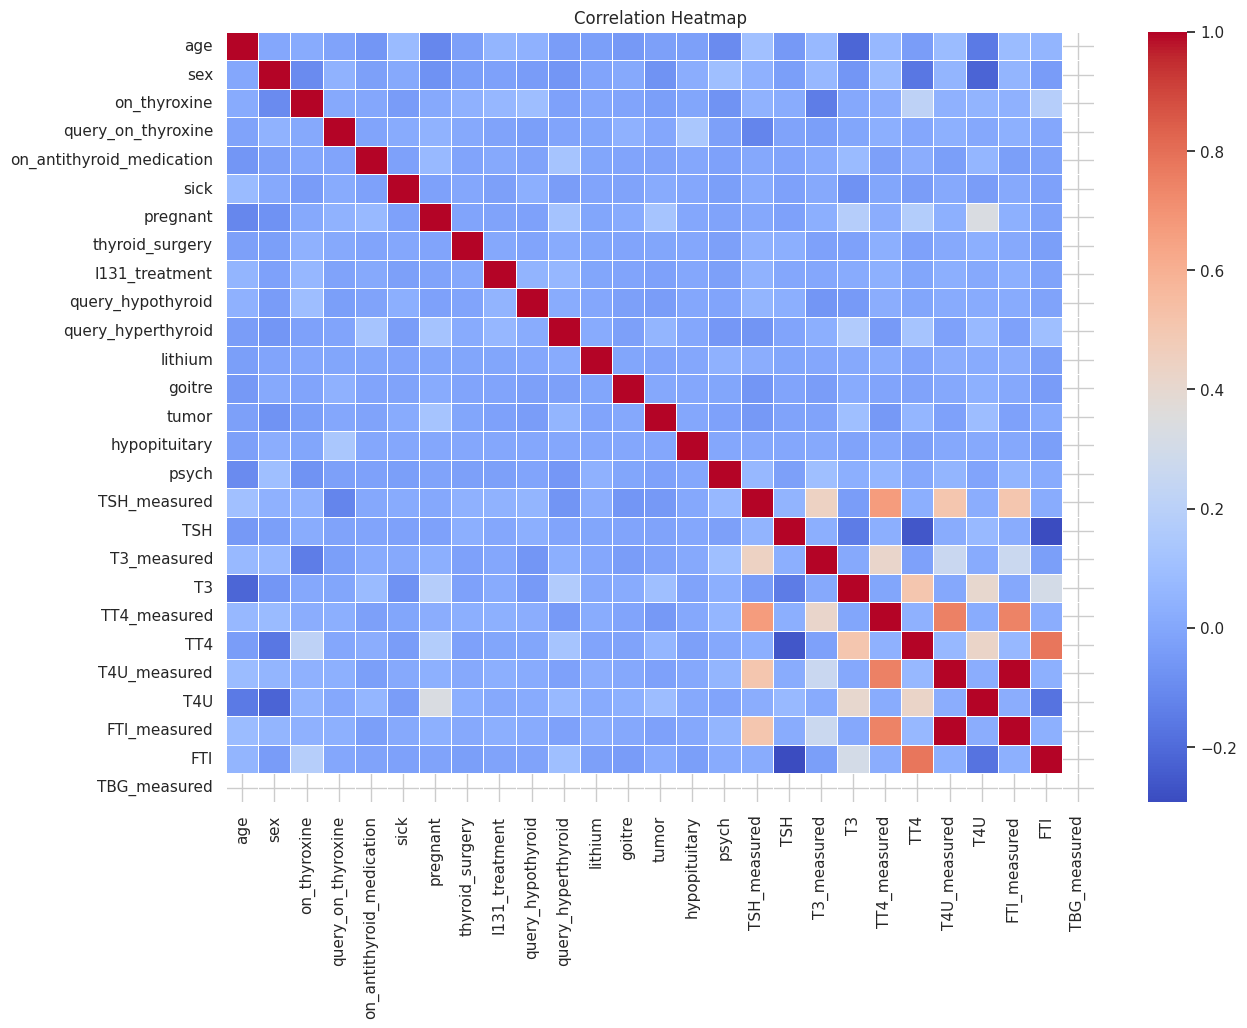

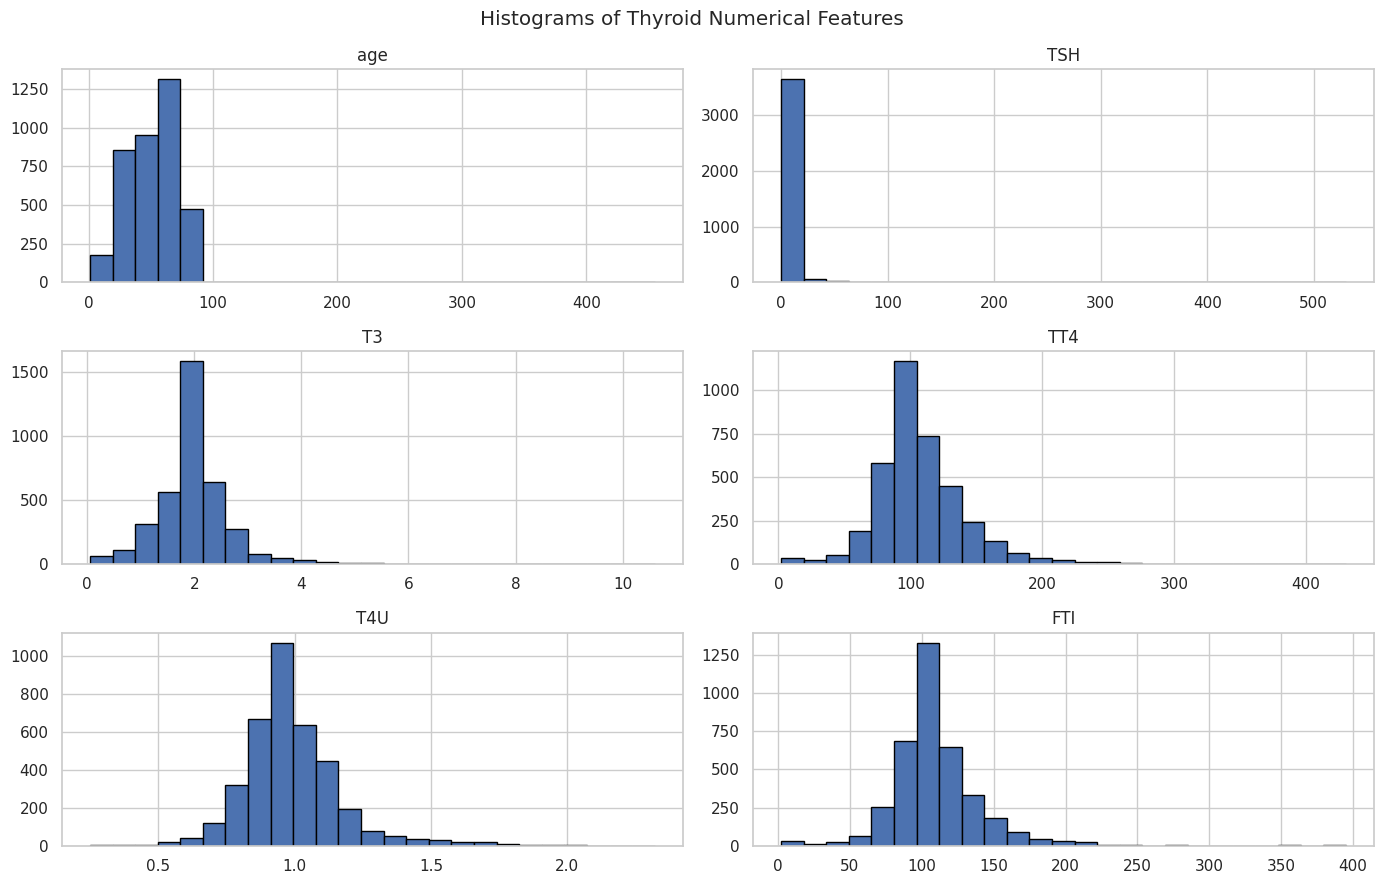

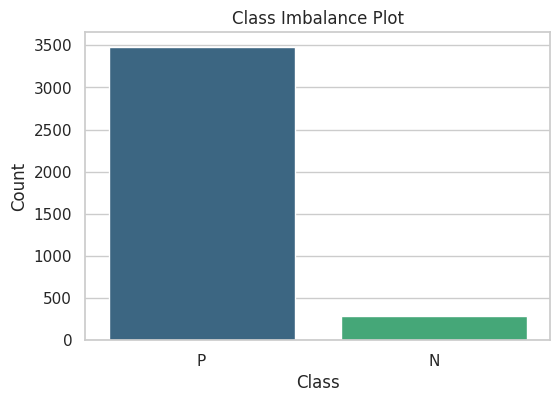

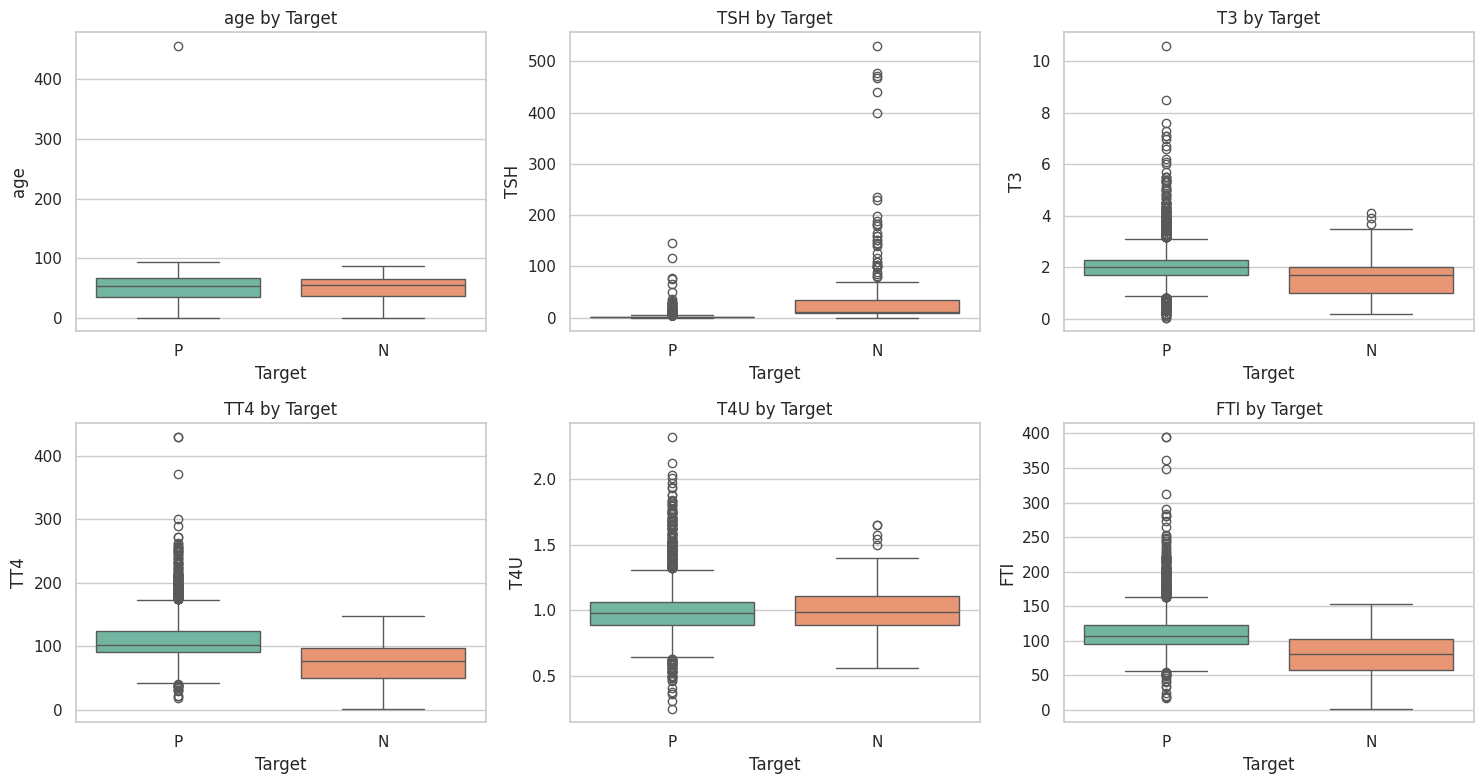

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.drop(columns=['referral_source']).corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# 2. Histograms
plot_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
df[plot_cols].hist(figsize=(14, 9), bins=25, edgecolor='black')
plt.suptitle("Histograms of Thyroid Numerical Features")
plt.tight_layout()
plt.show()

# 3. Class Imbalance Plot
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Target'], palette='viridis')
plt.title("Class Imbalance Plot")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 4. Boxplots for key labs by target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, plot_cols):
    sns.boxplot(data=df, x='Target', y=col, ax=ax, palette='Set2')
    ax.set_title(f"{col} by Target")
plt.tight_layout()
plt.show()


# CAUSAL STRUCTURE LEARNING


## Discretize Features


In [22]:
def qcut_labels(series, labels):
    return pd.qcut(series.rank(method='first'), q=len(labels), labels=labels)

df['Age_bin'] = pd.cut(
    df['age'],
    bins=[0, 30, 60, 120],
    labels=['young', 'middle', 'old'],
    include_lowest=True
)

df['TSH_bin'] = pd.cut(
    df['TSH'],
    bins=[-0.01, 0.4, 4.0, np.inf],
    labels=['low', 'normal', 'high'],
    include_lowest=True
)

df['T3_bin'] = qcut_labels(df['T3'], ['low', 'normal', 'high'])
df['TT4_bin'] = qcut_labels(df['TT4'], ['low', 'normal', 'high'])
df['T4U_bin'] = qcut_labels(df['T4U'], ['low', 'normal', 'high'])
df['FTI_bin'] = qcut_labels(df['FTI'], ['low', 'normal', 'high'])

df['Referral_bin'] = df['referral_source'].astype(str)

bayesian_df = df[
    [
        'Age_bin', 'sex', 'on_thyroxine', 'query_hypothyroid',
        'query_hyperthyroid', 'thyroid_surgery', 'sick', 'pregnant',
        'TSH_bin', 'T3_bin', 'TT4_bin', 'T4U_bin', 'FTI_bin',
        'Referral_bin', 'Target'
    ]
].copy()

for col in bayesian_df.columns:
    bayesian_df[col] = bayesian_df[col].astype(str)

bayesian_df.head()


,Age_bin,sex,on_thyroxine,query_hypothyroid,query_hyperthyroid,thyroid_surgery,sick,pregnant,TSH_bin,T3_bin,TT4_bin,T4U_bin,FTI_bin,Referral_bin,Target
0,middle,0.0,0,0,0,0,0,0,normal,high,high,high,normal,SVHC,P
1,young,0.0,0,0,0,0,0,0,high,normal,normal,normal,normal,other,P
2,middle,1.0,0,0,0,0,0,0,normal,normal,normal,low,high,other,P
3,old,0.0,1,0,0,0,0,0,low,low,high,normal,normal,other,P
4,old,0.0,0,0,0,0,0,0,normal,low,low,low,low,SVI,P


In [23]:
!pip install pgmpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 7.8 MB/s eta 0:00:00


## Learn DAG Structure


In [24]:
try:
    from pgmpy.estimators import HillClimbSearch, BIC, ExpertKnowledge
except ImportError:
    from pgmpy.estimators import HillClimbSearch, BicScore as BIC, ExpertKnowledge

hc = HillClimbSearch(bayesian_df)
best_structure = hc.estimate(scoring_method=BIC(bayesian_df))
print(best_structure.edges())


  0%|          | 0/1000000 [00:00<?, ?it/s]

[('on_thyroxine', 'Referral_bin'), ('on_thyroxine', 'TT4_bin'), ('on_thyroxine', 'TSH_bin'), ('on_thyroxine', 'Target'), ('on_thyroxine', 'query_hypothyroid'), ('TSH_bin', 'Target'), ('T3_bin', 'TT4_bin'), ('T3_bin', 'T4U_bin'), ('TT4_bin', 'FTI_bin'), ('TT4_bin', 'T4U_bin'), ('T4U_bin', 'FTI_bin'), ('T4U_bin', 'sex'), ('FTI_bin', 'TSH_bin'), ('Referral_bin', 'T3_bin'), ('Referral_bin', 'Age_bin'), ('Referral_bin', 'sex'), ('Referral_bin', 'sick'), ('Referral_bin', 'pregnant'), ('Referral_bin', 'query_hyperthyroid'), ('Target', 'query_hypothyroid')]


In [25]:
forbidden_edges = [
    ('Target', 'Age_bin'),
    ('Target', 'sex'),
    ('Target', 'pregnant'),
    ('Target', 'Referral_bin'),
    ('TSH_bin', 'sex'),
    ('T3_bin', 'sex'),
    ('TT4_bin', 'sex'),
    ('FTI_bin', 'sex'),
]

required_edges = [
    ('TSH_bin', 'Target'),
]

expert_knowledge = ExpertKnowledge(
    forbidden_edges=forbidden_edges,
    required_edges=required_edges
)

hc = HillClimbSearch(bayesian_df)
best_structure = hc.estimate(
    scoring_method=BIC(bayesian_df),
    expert_knowledge=expert_knowledge
)

print(best_structure.edges())


  0%|          | 0/1000000 [00:00<?, ?it/s]

[('on_thyroxine', 'Referral_bin'), ('on_thyroxine', 'TT4_bin'), ('on_thyroxine', 'TSH_bin'), ('on_thyroxine', 'Target'), ('on_thyroxine', 'query_hypothyroid'), ('TSH_bin', 'Target'), ('T3_bin', 'TT4_bin'), ('T3_bin', 'T4U_bin'), ('TT4_bin', 'FTI_bin'), ('TT4_bin', 'T4U_bin'), ('T4U_bin', 'FTI_bin'), ('T4U_bin', 'sex'), ('FTI_bin', 'TSH_bin'), ('Referral_bin', 'T3_bin'), ('Referral_bin', 'Age_bin'), ('Referral_bin', 'sex'), ('Referral_bin', 'sick'), ('Referral_bin', 'pregnant'), ('Referral_bin', 'query_hyperthyroid'), ('Target', 'query_hypothyroid')]


## DAG


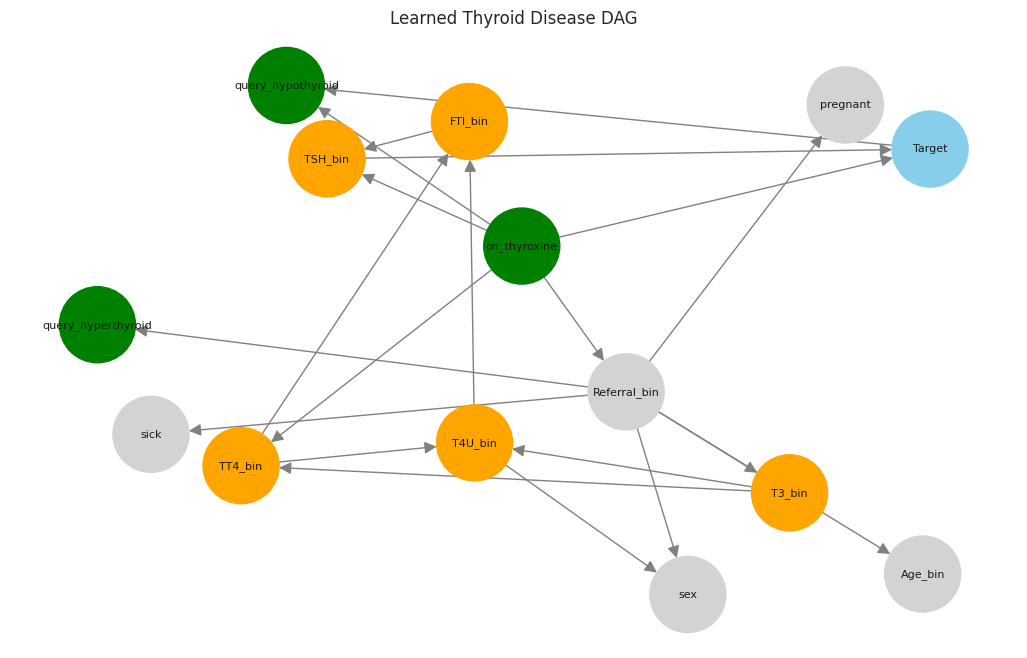

In [26]:
import os
import networkx as nx
import matplotlib.pyplot as plt

os.makedirs("thyroid_figures", exist_ok=True)

G = nx.DiGraph()
learned_edges = list(best_structure.edges())
G.add_edges_from(learned_edges)

node_colors = []
for node in G.nodes():
    if node in ['TSH_bin', 'T3_bin', 'TT4_bin', 'T4U_bin', 'FTI_bin']:
        node_colors.append('orange')
    elif node in ['on_thyroxine', 'query_hypothyroid', 'query_hyperthyroid', 'thyroid_surgery']:
        node_colors.append('green')
    elif node == 'Target':
        node_colors.append('skyblue')
    else:
        node_colors.append('lightgray')

plt.figure(figsize=(13, 8))
pos = nx.spring_layout(G, seed=42, k=1.3)
nx.draw_networkx(
    G, pos,
    with_labels=True,
    node_size=3000,
    font_size=8,
    arrowsize=18,
    node_color=node_colors,
    edge_color='gray'
)
plt.title("Learned Thyroid Disease DAG")
plt.axis('off')
plt.savefig("thyroid_figures/learned_dag.png", dpi=300, bbox_inches='tight')
plt.show()


In [27]:
expert_edges = [
    ('Age_bin', 'TSH_bin'),
    ('sex', 'pregnant'),
    ('pregnant', 'T4U_bin'),
    ('on_thyroxine', 'TSH_bin'),
    ('on_thyroxine', 'TT4_bin'),
    ('query_hypothyroid', 'TSH_bin'),
    ('query_hypothyroid', 'Target'),
    ('TSH_bin', 'Target'),
    ('T3_bin', 'Target'),
    ('TT4_bin', 'Target'),
    ('FTI_bin', 'Target'),
]


## Comparing with Clinical DAG


In [28]:
validation = []
for edge in learned_edges:
    validity = "Yes" if edge in expert_edges else "No/Partial"
    validation.append([edge, validity])

for row in validation:
    print(row)


[('on_thyroxine', 'Referral_bin'), 'No/Partial']
[('on_thyroxine', 'TT4_bin'), 'Yes']
[('on_thyroxine', 'TSH_bin'), 'Yes']
[('on_thyroxine', 'Target'), 'No/Partial']
[('on_thyroxine', 'query_hypothyroid'), 'No/Partial']
[('TSH_bin', 'Target'), 'Yes']
[('T3_bin', 'TT4_bin'), 'No/Partial']
[('T3_bin', 'T4U_bin'), 'No/Partial']
[('TT4_bin', 'FTI_bin'), 'No/Partial']
[('TT4_bin', 'T4U_bin'), 'No/Partial']
[('T4U_bin', 'FTI_bin'), 'No/Partial']
[('T4U_bin', 'sex'), 'No/Partial']
[('FTI_bin', 'TSH_bin'), 'No/Partial']
[('Referral_bin', 'T3_bin'), 'No/Partial']
[('Referral_bin', 'Age_bin'), 'No/Partial']
[('Referral_bin', 'sex'), 'No/Partial']
[('Referral_bin', 'sick'), 'No/Partial']
[('Referral_bin', 'pregnant'), 'No/Partial']
[('Referral_bin', 'query_hyperthyroid'), 'No/Partial']
[('Target', 'query_hypothyroid'), 'No/Partial']


## Structural Hamming Distance


In [29]:
expert_set = set(expert_edges)
learned_set = set(learned_edges)

extra_edges = learned_set - expert_set
missing_edges = expert_set - learned_set
shd = len(extra_edges) + len(missing_edges)

print("Extra edges:", extra_edges)
print("Missing edges:", missing_edges)
print("SHD:", shd)

pd.DataFrame(validation, columns=['Learned Edge', 'Clinically Valid']).to_csv(
    "thyroid_clinical_validation.csv",
    index=False
)


Extra edges: {('FTI_bin', 'TSH_bin'), ('on_thyroxine', 'query_hypothyroid'), ('TT4_bin', 'FTI_bin'), ('on_thyroxine', 'Referral_bin'), ('T4U_bin', 'FTI_bin'), ('Referral_bin', 'T3_bin'), ('T4U_bin', 'sex'), ('on_thyroxine', 'Target'), ('T3_bin', 'TT4_bin'), ('Referral_bin', 'sick'), ('Referral_bin', 'sex'), ('T3_bin', 'T4U_bin'), ('Referral_bin', 'Age_bin'), ('TT4_bin', 'T4U_bin'), ('Target', 'query_hypothyroid'), ('Referral_bin', 'query_hyperthyroid'), ('Referral_bin', 'pregnant')}
Missing edges: {('Age_bin', 'TSH_bin'), ('TT4_bin', 'Target'), ('pregnant', 'T4U_bin'), ('query_hypothyroid', 'Target'), ('T3_bin', 'Target'), ('FTI_bin', 'Target'), ('sex', 'pregnant'), ('query_hypothyroid', 'TSH_bin')}
SHD: 25


# BAYESIAN NETWORK TRAINING


## Learned Model


In [30]:
try:
    from pgmpy.models import DiscreteBayesianNetwork
except ImportError:
    from pgmpy.models import BayesianNetwork as DiscreteBayesianNetwork

learned_model = DiscreteBayesianNetwork(best_structure.edges())
learned_model.fit(bayesian_df)


## Conditional Probability Tables


In [31]:
with open("thyroid_all_cpds.txt", "w") as f:
    for cpd in learned_model.get_cpds():
        f.write(str(cpd))
        f.write("\n\n" + "="*80 + "\n\n")
        print(cpd)
        print("\n")


+-----------------+----------+
| on_thyroxine(0) | 0.876988 |
+-----------------+----------+
| on_thyroxine(1) | 0.123012 |
+-----------------+----------+


+---------------------+----------------------+----------------------+
| on_thyroxine        | on_thyroxine(0)      | on_thyroxine(1)      |
+---------------------+----------------------+----------------------+
| Referral_bin(STMW)  | 0.03083434099153567  | 0.021551724137931036 |
+---------------------+----------------------+----------------------+
| Referral_bin(SVHC)  | 0.1133615477629988   | 0.023706896551724137 |
+---------------------+----------------------+----------------------+
| Referral_bin(SVHD)  | 0.009673518742442563 | 0.015086206896551725 |
+---------------------+----------------------+----------------------+
| Referral_bin(SVI)   | 0.3041112454655381   | 0.0603448275862069   |
+---------------------+----------------------+----------------------+
| Referral_bin(other) | 0.5420193470374849   | 0.8793103448275862   |
+--

In [32]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(learned_model)

def target_probability(query_result, positive_label='N'):
    states = list(query_result.state_names['Target'])
    return float(query_result.values[states.index(positive_label)])

queries = [
    {'TSH_bin': 'high', 'FTI_bin': 'low'},
    {'T3_bin': 'low', 'TT4_bin': 'low', 'TSH_bin': 'high'},
    {'query_hypothyroid': '1'},
]

for evidence in queries:
    q = infer.query(variables=['Target'], evidence=evidence)
    print("Evidence:", evidence)
    print(q)


Evidence: {'TSH_bin': 'high', 'FTI_bin': 'low'}
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(N) |        0.5447 |
+-----------+---------------+
| Target(P) |        0.4553 |
+-----------+---------------+
Evidence: {'T3_bin': 'low', 'TT4_bin': 'low', 'TSH_bin': 'high'}
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(N) |        0.5631 |
+-----------+---------------+
| Target(P) |        0.4369 |
+-----------+---------------+
Evidence: {'query_hypothyroid': '1'}
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(N) |        0.1667 |
+-----------+---------------+
| Target(P) |        0.8333 |
+-----------+---------------+


In [33]:
print(learned_model.get_cpds('Target'))


+--------------+-----+-----------------+
| TSH_bin      | ... | TSH_bin(normal) |
+--------------+-----+-----------------+
| on_thyroxine | ... | on_thyroxine(1) |
+--------------+-----+-----------------+
| Target(N)    | ... | 0.0             |
+--------------+-----+-----------------+
| Target(P)    | ... | 1.0             |
+--------------+-----+-----------------+


## Expert Model


In [34]:
expert_model = DiscreteBayesianNetwork(expert_edges)
expert_model.fit(bayesian_df)


# PROBABILISTIC INFERENCE


## Patient-Level Risk Prediction


In [35]:
infer_learned = VariableElimination(learned_model)
infer_expert = VariableElimination(expert_model)

query = {
    'TSH_bin': 'high',
    'FTI_bin': 'low'
}

q1 = infer_learned.query(variables=['Target'], evidence=query)
print("Learned model")
print(q1)

q2 = infer_expert.query(variables=['Target'], evidence=query)
print("Expert model")
print(q2)


Learned model
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(N) |        0.5447 |
+-----------+---------------+
| Target(P) |        0.4553 |
+-----------+---------------+
Expert model
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(N) |        0.4343 |
+-----------+---------------+
| Target(P) |        0.5657 |
+-----------+---------------+


## Comparison between Learned and Expert Model


In [36]:
y_true = bayesian_df['Target']


def predict(model_infer, row, model_nodes):
    evidence = {
        k: v
        for k, v in row.items()
        if k in model_nodes and k != 'Target'
    }
    q = model_infer.query(variables=['Target'], evidence=evidence)
    probs = q.values
    pred = q.state_names['Target'][probs.argmax()]
    return pred

learned_nodes = set(learned_model.nodes())
expert_nodes = set(expert_model.nodes())

y_pred_learned = []
y_pred_expert = []

for _, row in bayesian_df.iterrows():
    y_pred_learned.append(predict(infer_learned, row, learned_nodes))
    y_pred_expert.append(predict(infer_expert, row, expert_nodes))


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

positive_label = 'N'

print("Learned DAG")
print("Accuracy", accuracy_score(y_true, y_pred_learned))
print("Precision", precision_score(y_true, y_pred_learned, pos_label=positive_label))
print("Recall", recall_score(y_true, y_pred_learned, pos_label=positive_label))
print("F1 score", f1_score(y_true, y_pred_learned, pos_label=positive_label))

print("\nExpert DAG")
print("Accuracy", accuracy_score(y_true, y_pred_expert))
print("Precision", precision_score(y_true, y_pred_expert, pos_label=positive_label))
print("Recall", recall_score(y_true, y_pred_expert, pos_label=positive_label))
print("F1 score", f1_score(y_true, y_pred_expert, pos_label=positive_label))


Learned DAG
Accuracy 0.9496288441145281
Precision 0.6095444685466378
Recall 0.9656357388316151
F1 score 0.7473404255319149

Expert DAG
Accuracy 0.9509544008483564
Precision 0.6586826347305389
Recall 0.7560137457044673
F1 score 0.704


# UNCERTAINTY AWARENESS


## Bootstrap Sampling


In [38]:
N = 100
risk_scores = []
evidence = {'TSH_bin': 'high', 'FTI_bin': 'low'}

for i in range(N):
    sample_df = bayesian_df.sample(n=len(bayesian_df), replace=True, random_state=i)
    bootstrap_model = DiscreteBayesianNetwork(best_structure.edges())
    bootstrap_model.fit(sample_df)
    bootstrap_infer = VariableElimination(bootstrap_model)
    q = bootstrap_infer.query(variables=['Target'], evidence=evidence)
    risk_scores.append(target_probability(q, positive_label=positive_label))

mean_risk = np.mean(risk_scores)
std_risk = np.std(risk_scores)
lower = mean_risk - 1.96 * std_risk
upper = mean_risk + 1.96 * std_risk

print(f"Risk = {mean_risk:.2f} ? {std_risk:.2f}")
print(f"95% CI = [{lower:.2f}, {upper:.2f}]")


Risk = 0.54 ? 0.03
95% CI = [0.49, 0.59]


## Uncertainty Distribution


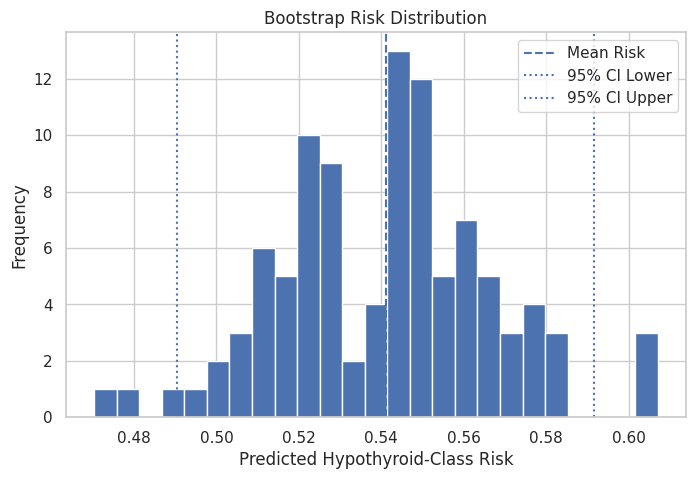

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(risk_scores, bins=25)
plt.axvline(mean_risk, linestyle='--', label='Mean Risk')
plt.axvline(lower, linestyle=':', label='95% CI Lower')
plt.axvline(upper, linestyle=':', label='95% CI Upper')
plt.xlabel("Predicted Hypothyroid-Class Risk")
plt.ylabel("Frequency")
plt.title("Bootstrap Risk Distribution")
plt.legend()
plt.savefig("thyroid_figures/bootstrap_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()


# COUNTERFACTUAL INTERVENTION ENGINE


In [40]:
infer = VariableElimination(learned_model)

def get_risk(evidence):
    q = infer.query(variables=['Target'], evidence=evidence)
    return target_probability(q, positive_label=positive_label)

patient = {
    'TSH_bin': 'high',
    'FTI_bin': 'low'
}

old_risk = get_risk(patient)
print("Old Risk:", old_risk)

intervention = {
    'TSH_bin': 'normal',
    'FTI_bin': 'normal'
}

new_risk = get_risk(intervention)
print("New Risk:", new_risk)


Old Risk: 0.5447465570194603
New Risk: 0.0


## Intervention Comparison Table


In [41]:
results = [
    ['Normalize TSH', old_risk, get_risk({'TSH_bin': 'normal', 'FTI_bin': 'low'})],
    ['Normalize FTI', old_risk, get_risk({'TSH_bin': 'high', 'FTI_bin': 'normal'})],
    ['Normalize TSH and FTI', old_risk, new_risk],
]

df_interventions = pd.DataFrame(results, columns=['Intervention', 'Risk Before', 'Risk After'])
print(df_interventions)
df_interventions.to_csv("thyroid_intervention_results.csv", index=False)


            Intervention  Risk Before  Risk After
0          Normalize TSH     0.544747    0.000000
1          Normalize FTI     0.544747    0.514459
2  Normalize TSH and FTI     0.544747    0.000000


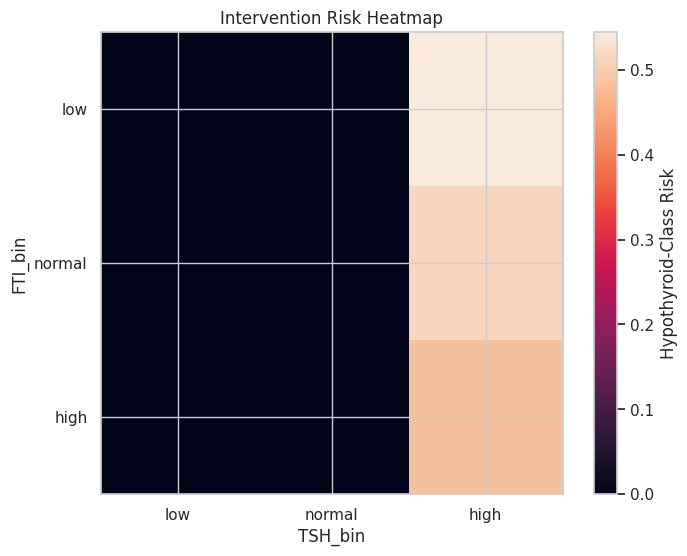

In [42]:
tsh_levels = ['low', 'normal', 'high']
fti_levels = ['low', 'normal', 'high']

heatmap_data = []
for fti in fti_levels:
    row = []
    for tsh in tsh_levels:
        row.append(get_risk({'TSH_bin': tsh, 'FTI_bin': fti}))
    heatmap_data.append(row)

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_data)
plt.colorbar(label='Hypothyroid-Class Risk')
plt.xticks(range(len(tsh_levels)), tsh_levels)
plt.yticks(range(len(fti_levels)), fti_levels)
plt.xlabel("TSH_bin")
plt.ylabel("FTI_bin")
plt.title("Intervention Risk Heatmap")
plt.savefig("thyroid_figures/intervention_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


# OPTIMIZATION ENGINE


In [43]:
patient = {'TSH_bin': 'high', 'FTI_bin': 'low'}
baseline_risk = get_risk(patient)
print(baseline_risk)


0.5447465570194603


In [44]:
target_risk = 0.30
results = []

for tsh in tsh_levels:
    for fti in fti_levels:
        intervention = {'TSH_bin': tsh, 'FTI_bin': fti}
        risk = get_risk(intervention)
        distance = int(tsh != patient['TSH_bin']) + int(fti != patient['FTI_bin'])
        results.append([tsh, fti, risk, distance])

df_opt = pd.DataFrame(results, columns=['TSH_bin', 'FTI_bin', 'Risk', 'Distance'])
safe_df = df_opt[df_opt['Risk'] < target_risk]

if len(safe_df) == 0:
    print("No feasible intervention found.")
    print("Minimum achievable risk:", df_opt['Risk'].min())
else:
    best = safe_df.sort_values(by='Distance').iloc[0]
    print(best)

print(df_opt.sort_values(by='Risk'))


TSH_bin          low
FTI_bin          low
Risk        0.001473
Distance           1
Name: 0, dtype: object
  TSH_bin FTI_bin      Risk  Distance
3  normal     low  0.000000         1
4  normal  normal  0.000000         2
5  normal    high  0.000000         2
2     low    high  0.001160         2
1     low  normal  0.001396         2
0     low     low  0.001473         1
8    high    high  0.484345         1
7    high  normal  0.514459         1
6    high     low  0.544747         0


## Training ML Baselines


In [45]:
!pip install imbalanced-learn catboost

In [46]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

X = df.drop(columns=['Target'])
y = df['Target'].astype(str)
positive_label = 'N'

categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', one_hot, categorical_features),
    ],
    remainder='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'SVM RBF': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB(),
}

try:
    from catboost import CatBoostClassifier
    base_models['CatBoost'] = CatBoostClassifier(verbose=False, random_state=42, auto_class_weights='Balanced')
except Exception:
    print("CatBoost is not available; continuing with sklearn models.")

voting_estimators = [
    ('lr', LogisticRegression(max_iter=3000, class_weight='balanced')),
    ('rf', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced')),
    ('et', ExtraTreesClassifier(n_estimators=250, random_state=42, class_weight='balanced')),
    ('gb', GradientBoostingClassifier(random_state=42)),
]

base_models['Soft Voting Ensemble'] = VotingClassifier(
    estimators=voting_estimators,
    voting='soft'
)

base_models['Stacking Ensemble'] = StackingClassifier(
    estimators=voting_estimators,
    final_estimator=LogisticRegression(max_iter=3000, class_weight='balanced'),
    stack_method='predict_proba',
    cv=3,
    n_jobs=-1
)

trained_models = {}
model_rows = []

for name, estimator in base_models.items():
    print(f"Training {name}...")
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    classes = list(model.classes_)

    if positive_label in classes:
        pos_idx = classes.index(positive_label)
    else:
        pos_idx = -1

    y_prob = model.predict_proba(X_test)[:, pos_idx]

    model_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        'Recall': recall_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        'AUC Score': roc_auc_score((y_test == positive_label).astype(int), y_prob),
    })
    trained_models[name] = model

model_results = pd.DataFrame(model_rows).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
print("\n===== ML MODEL COMPARISON =====\n")
print(model_results)
model_results.to_csv("thyroid_ml_model_comparison.csv", index=False)

best_ml_row = model_results.iloc[0]
print("\nBest ML model:", best_ml_row['Model'])

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training AdaBoost...
Training SVM RBF...
Training KNN...
Training Naive Bayes...
Training CatBoost...
Training Soft Voting Ensemble...
Training Stacking Ensemble...

===== ML MODEL COMPARISON =====

                   Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0      Gradient Boosting  1.000000   1.000000  1.000000  1.000000   1.000000
1          Decision Tree  0.998675   0.983051  1.000000  0.991453   0.999283
2      Stacking Ensemble  0.998675   0.983051  1.000000  0.991453   1.000000
3               CatBoost  0.997351   0.966667  1.000000  0.983051   0.999975
4   Soft Voting Ensemble  0.997351   0.966667  1.000000  0.983051   0.999975
5          Random Forest  0.993377   0.934426  0.982759  0.957983   0.999876
6               AdaBoost  0.992053   0.919355  0.982759  0.950000   0.998578
7            Extra Trees  0.972185   0.824561  

## All Models vs Bayesian Network



===== ALL MODELS vs BAYESIAN NETWORK =====

                   Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0      Gradient Boosting  1.000000   1.000000  1.000000  1.000000   1.000000
1          Decision Tree  0.998675   0.983051  1.000000  0.991453   0.999283
2      Stacking Ensemble  0.998675   0.983051  1.000000  0.991453   1.000000
3               CatBoost  0.997351   0.966667  1.000000  0.983051   0.999975
4   Soft Voting Ensemble  0.997351   0.966667  1.000000  0.983051   0.999975
5          Random Forest  0.993377   0.934426  0.982759  0.957983   0.999876
6               AdaBoost  0.992053   0.919355  0.982759  0.950000   0.998578
7            Extra Trees  0.972185   0.824561  0.810345  0.817391   0.992913
8                SVM RBF  0.950993   0.612903  0.982759  0.754967   0.984515
9       Bayesian Network  0.949629   0.609544  0.965636  0.747340   0.974626
10   Logistic Regression  0.943046   0.575758  0.982759  0.726115   0.991045
11           Naive Bayes  0.927

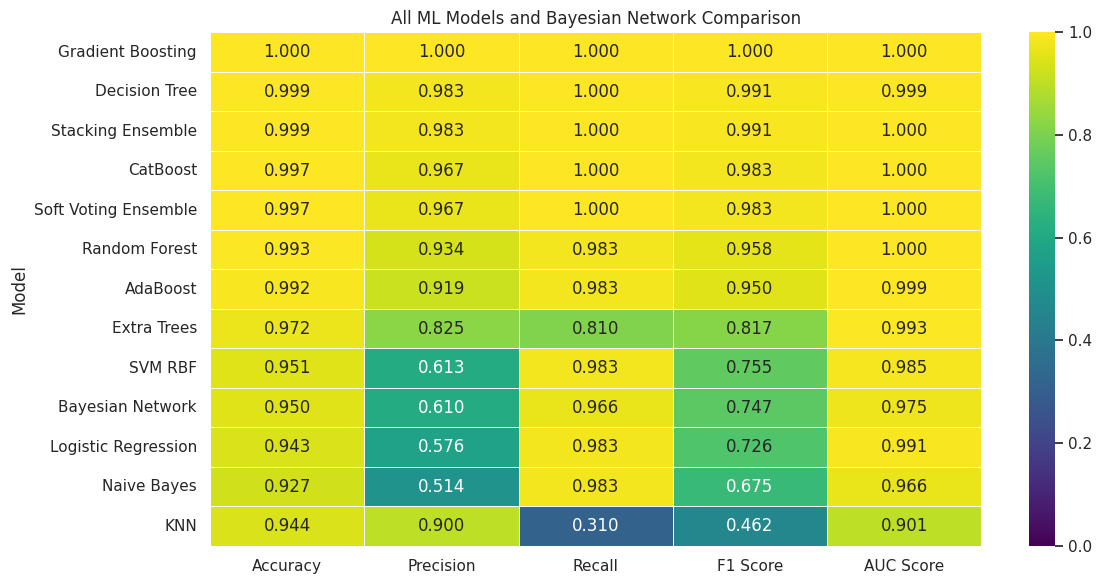

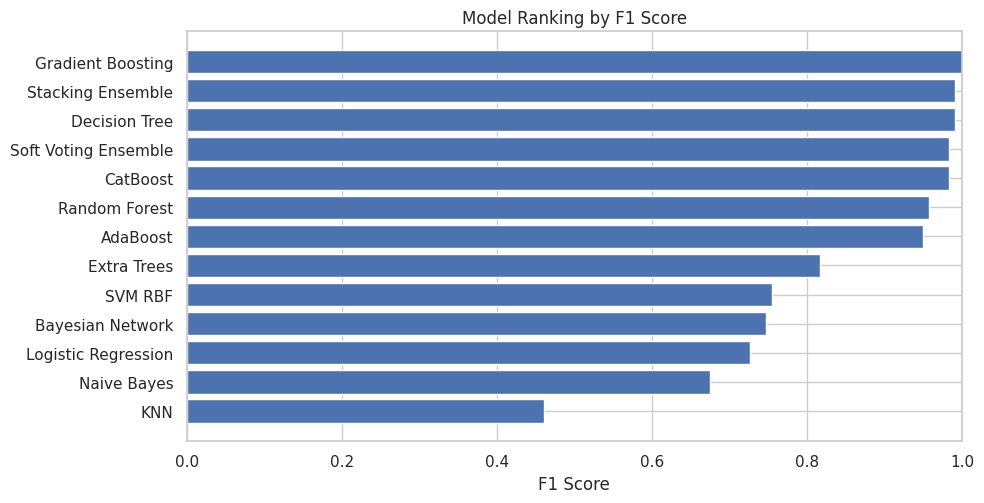

In [47]:
bn_accuracy = accuracy_score(y_true, y_pred_learned)
bn_precision = precision_score(y_true, y_pred_learned, pos_label=positive_label, zero_division=0)
bn_recall = recall_score(y_true, y_pred_learned, pos_label=positive_label, zero_division=0)
bn_f1 = f1_score(y_true, y_pred_learned, pos_label=positive_label, zero_division=0)

bn_probs = []
for _, row in bayesian_df.iterrows():
    evidence = {k: v for k, v in row.items() if k in learned_nodes and k != 'Target'}
    q = infer_learned.query(variables=['Target'], evidence=evidence)
    bn_probs.append(target_probability(q, positive_label=positive_label))

bn_auc = roc_auc_score((y_true == positive_label).astype(int), bn_probs)

bn_row = {
    'Model': 'Bayesian Network',
    'Accuracy': bn_accuracy,
    'Precision': bn_precision,
    'Recall': bn_recall,
    'F1 Score': bn_f1,
    'AUC Score': bn_auc,
}

all_results = pd.concat(
    [model_results, pd.DataFrame([bn_row])],
    ignore_index=True
).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("\n===== ALL MODELS vs BAYESIAN NETWORK =====\n")
print(all_results)
all_results.to_csv("thyroid_all_models_vs_bayesian.csv", index=False)

import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("thyroid_figures", exist_ok=True)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC Score']
plot_df = all_results.set_index('Model')[metrics]

plt.figure(figsize=(12, max(6, 0.45 * len(plot_df))))
sns.heatmap(
    plot_df,
    annot=True,
    cmap='viridis',
    fmt='.3f',
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title("All ML Models and Bayesian Network Comparison")
plt.tight_layout()
plt.savefig("thyroid_figures/all_models_vs_bayesian_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

ranked = all_results.sort_values(by='F1 Score', ascending=True)
plt.figure(figsize=(10, max(5, 0.4 * len(ranked))))
plt.barh(ranked['Model'], ranked['F1 Score'])
plt.xlabel("F1 Score")
plt.title("Model Ranking by F1 Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("thyroid_figures/model_f1_ranking.png", dpi=300, bbox_inches='tight')
plt.show()

# LLM EXPLANATION


In [48]:
!pip install groq

In [49]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GROQ_API_KEY")

In [50]:
# Optional: set GROQ_API_KEY in your environment, then uncomment the install/import lines.

from groq import Groq
client = Groq(api_key=secret_value_0)

dag_edges = list(learned_model.edges())
risk = round(old_risk, 4)
confidence_interval = [round(lower, 4), round(upper, 4)]
interventions = df_interventions.to_dict(orient='records')

prompt = f"""
You are an AI clinical reasoning assistant.

A Bayesian causal network was trained for thyroid disease analysis.
The modeled positive label is {positive_label}.

Learned causal DAG edges:
{dag_edges}

Predicted thyroid disease risk:
{risk}

95% confidence interval:
{confidence_interval}

Intervention analysis:
{interventions}

Generate:
1. Primary risk drivers
2. Interpretable clinical explanation
3. Intervention summary
4. Confidence and uncertainty notes
"""

print(prompt)

response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": prompt}],
)
print(response.choices[0].message.content)



You are an AI clinical reasoning assistant.

A Bayesian causal network was trained for thyroid disease analysis.
The modeled positive label is N.

Learned causal DAG edges:
[('on_thyroxine', 'Referral_bin'), ('on_thyroxine', 'TT4_bin'), ('on_thyroxine', 'TSH_bin'), ('on_thyroxine', 'Target'), ('on_thyroxine', 'query_hypothyroid'), ('Referral_bin', 'T3_bin'), ('Referral_bin', 'Age_bin'), ('Referral_bin', 'sex'), ('Referral_bin', 'sick'), ('Referral_bin', 'pregnant'), ('Referral_bin', 'query_hyperthyroid'), ('TT4_bin', 'FTI_bin'), ('TT4_bin', 'T4U_bin'), ('TSH_bin', 'Target'), ('Target', 'query_hypothyroid'), ('T3_bin', 'TT4_bin'), ('T3_bin', 'T4U_bin'), ('T4U_bin', 'FTI_bin'), ('T4U_bin', 'sex'), ('FTI_bin', 'TSH_bin')]

Predicted thyroid disease risk:
0.5447

95% confidence interval:
[np.float64(0.4904), np.float64(0.5917)]

Intervention analysis:
[{'Intervention': 'Normalize TSH', 'Risk Before': 0.5447465570194603, 'Risk After': 0.0}, {'Intervention': 'Normalize FTI', 'Risk Before': 

# EVALUATION


In [51]:
best_overall_row = all_results.sort_values(by='F1 Score', ascending=False).iloc[0]
bayesian_row = all_results[all_results['Model'] == 'Bayesian Network'].iloc[0]

final_results = pd.DataFrame({
    'Metric': [
        'Best Overall Model',
        'Best Overall Accuracy',
        'Best Overall F1 Score',
        'Best Overall AUC Score',
        'Best ML Model',
        'Bayesian Network Accuracy',
        'Bayesian Network F1 Score',
        'Bayesian Network AUC Score',
        'SHD',
        'Confidence Interval Width',
        'Risk Reduction (%)'
    ],
    'Value': [
        best_overall_row['Model'],
        round(best_overall_row['Accuracy'], 4),
        round(best_overall_row['F1 Score'], 4),
        round(best_overall_row['AUC Score'], 4),
        best_ml_row['Model'],
        round(bayesian_row['Accuracy'], 4),
        round(bayesian_row['F1 Score'], 4),
        round(bayesian_row['AUC Score'], 4),
        shd,
        round(upper - lower, 4),
        round(((old_risk - new_risk) / old_risk) * 100, 2) if old_risk else 0
    ]
})

print("\n===== FINAL SUMMARY TABLE =====\n")
print(final_results)

print("\n===== FULL MODEL COMPARISON TABLE =====\n")
print(all_results)

final_results.to_csv("thyroid_final_metrics_table.csv", index=False)
all_results.to_csv("thyroid_final_all_models_comparison.csv", index=False)


===== FINAL SUMMARY TABLE =====

                        Metric              Value
0           Best Overall Model  Gradient Boosting
1        Best Overall Accuracy                1.0
2        Best Overall F1 Score                1.0
3       Best Overall AUC Score                1.0
4                Best ML Model  Gradient Boosting
5    Bayesian Network Accuracy             0.9496
6    Bayesian Network F1 Score             0.7473
7   Bayesian Network AUC Score             0.9746
8                          SHD                 25
9    Confidence Interval Width             0.1013
10          Risk Reduction (%)              100.0

===== FULL MODEL COMPARISON TABLE =====

                   Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0      Gradient Boosting  1.000000   1.000000  1.000000  1.000000   1.000000
1          Decision Tree  0.998675   0.983051  1.000000  0.991453   0.999283
2      Stacking Ensemble  0.998675   0.983051  1.000000  0.991453   1.000000
3               